# Exercise: Recommendation System Optimization
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Apply RL to recommendation systems
- Optimize user engagement
- Balance exploration and exploitation
- Apply to e-commerce

## Real-World Context

Optimize product recommendations to maximize user engagement.

**Task**: Build RL-based recommendation system.

---

## Task 1: Recommendation Environment (30 points)

Create recommendation environment:
1. Define user preferences
2. Define products
3. Define reward function

## Exercise Brief

This exercise checks whether students can apply RL thinking to an application scenario, not only to a textbook algorithm.

They should identify states, actions, rewards, risks, and trade-offs in a realistic decision problem.

Why this matters: Unit 5 is about transfer of understanding from theory to applications.

This exercise verifies that students can reason about that transfer clearly.

## Exercise Goal

This exercise asks you to formulate an application problem, define the RL pieces,
and reason about the trade-offs rather than jumping straight to a large training system.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Recommendation policy: what to show the user.
- Feedback signal: clicks or other user response.
- Long-term engagement: more than one-step reward.
- Preference uncertainty: not knowing the user fully yet.

### Quick Check
- Why can recommendation be an RL problem?
- What goes wrong if we optimize only immediate clicks?
- Where are states, actions, and rewards here?

### Common Mistakes
- Reducing recommendation to one-step prediction.
- Using the wrong reward proxy.
- Ignoring exploration of user preferences.


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np


# Define class `RecommendationEnv`: groups methods/attributes for one concept; see methods in the indented block.
class RecommendationEnv:
    # Define function `__init__`: parameters in parentheses; the indented body below implements its behavior step-by-step.
    def __init__(self, user_preferences, product_vectors):
        # Assign/update a variable used later in this cell or in other cells.
        self.user_preferences = np.asarray(user_preferences, dtype=float)
        # Assign/update a variable used later in this cell or in other cells.
        self.product_vectors = np.asarray(product_vectors, dtype=float)
        # Assign/update a variable used later in this cell or in other cells.
        self.n_products = len(product_vectors)
        # Assign/update a variable used later in this cell or in other cells.
        self.current_user = 0

    # Define function `reset`: parameters in parentheses; the indented body below implements its behavior step-by-step.
    def reset(self, user_id=0):
        # Assign/update a variable used later in this cell or in other cells.
        self.current_user = user_id
        # Return a value from this function to its caller.
        return self.user_preferences[user_id]

    # Define function `step`: parameters in parentheses; the indented body below implements its behavior step-by-step.
    def step(self, action):
        # Assign/update a variable used later in this cell or in other cells.
        user_vector = self.user_preferences[self.current_user]
        # Assign/update a variable used later in this cell or in other cells.
        product_vector = self.product_vectors[action]
        # Unpack the one-step model output from transition(state, action).
        reward = float(np.dot(user_vector, product_vector))
        # Assign/update a variable used later in this cell or in other cells.
        done = True
        # Assign/update a variable used later in this cell or in other cells.
        info = {"user_id": self.current_user}
        # Return a value from this function to its caller.
        return user_vector, reward, done, info


# Assign/update a variable used later in this cell or in other cells.
user_preferences = [
    # Execute: [0.9, 0.1, 0.0],
    [0.9, 0.1, 0.0],
    # Execute: [0.1, 0.8, 0.2],
    [0.1, 0.8, 0.2],
    # Execute: [0.2, 0.2, 0.9],
    [0.2, 0.2, 0.9],
# Execute: ]
]
# Assign/update a variable used later in this cell or in other cells.
product_vectors = [
    # Execute: [1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    # Execute: [0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0],
    # Execute: [0.0, 0.0, 1.0],
    [0.0, 0.0, 1.0],
    # Execute: [0.6, 0.3, 0.1],
    [0.6, 0.3, 0.1],
# Execute: ]
]

# Assign/update a variable used later in this cell or in other cells.
env = RecommendationEnv(user_preferences, product_vectors)
# Create or choose a variable used in the Bellman warm-up demo.
state = env.reset(user_id=1)
# Print text to the notebook cell output (console).
print("Sample user state:", state)
# Print text to the notebook cell output (console).
print("Reward for recommending product 1:", env.step(1)[1])


Sample user state: [0.1 0.8 0.2]
Reward for recommending product 1: 0.8


## Task 2: RL Agent (35 points)

Implement an RL-style decision component appropriate to your chosen setup:
1. A policy, scoring rule, or value estimate
2. A clear action-selection rule
3. An evaluation loop that shows how the agent behaves

You do **not** need a full deep-learning training stack unless your instructor explicitly asks for one.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Task 2: simple value-based recommendation baseline

# Define function `recommend_greedily`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def recommend_greedily(env, user_id):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = env.reset(user_id=user_id)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Loop header: repeat the indented block for each item in the iterable.
    for action in range(env.n_products):
        # Assign/update a variable used later in this cell or in other cells.
        _, reward, _, _ = env.step(action)
        # Append one value to a list (mutates the list in place).
        rewards.append(reward)
    # Assign/update a variable used later in this cell or in other cells.
    best_action = int(np.argmax(rewards))
    # Return a value from this function to its caller.
    return best_action, rewards


# Loop header: repeat the indented block for each item in the iterable.
for user_id in range(len(user_preferences)):
    # Assign/update a variable used later in this cell or in other cells.
    best_action, rewards = recommend_greedily(env, user_id)
    # Print text to the notebook cell output (console).
    print(f"User {user_id}: rewards={np.round(rewards, 2)} -> best product={best_action}")

# Print text to the notebook cell output (console).
print("\nReflection:")
# Print text to the notebook cell output (console).
print("- In a real RL system, rewards would come over time, not from a direct dot product.")
# Print text to the notebook cell output (console).
print("- This baseline still helps you define states, actions, and rewards clearly.")


User 0: rewards=[0.9  0.1  0.   0.57] -> best product=0
User 1: rewards=[0.1  0.8  0.2  0.32] -> best product=1
User 2: rewards=[0.2  0.2  0.9  0.27] -> best product=2

Reflection:
- In a real RL system, rewards would come over time, not from a direct dot product.
- This baseline still helps you define states, actions, and rewards clearly.


## Task 3: Real-World Application (35 points)

Write short answers for the following:

1. What is the **state** in your recommendation problem?
2. What is the **action**?
3. What is the **reward**, and what user behavior does it represent?
4. What exploration risk exists in this setting?
5. Name one ethical issue such as manipulation, filter bubbles, or unfair exposure.

**Submission**: complete notebook with code and written reasoning.

**Grading**: 100 points total

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


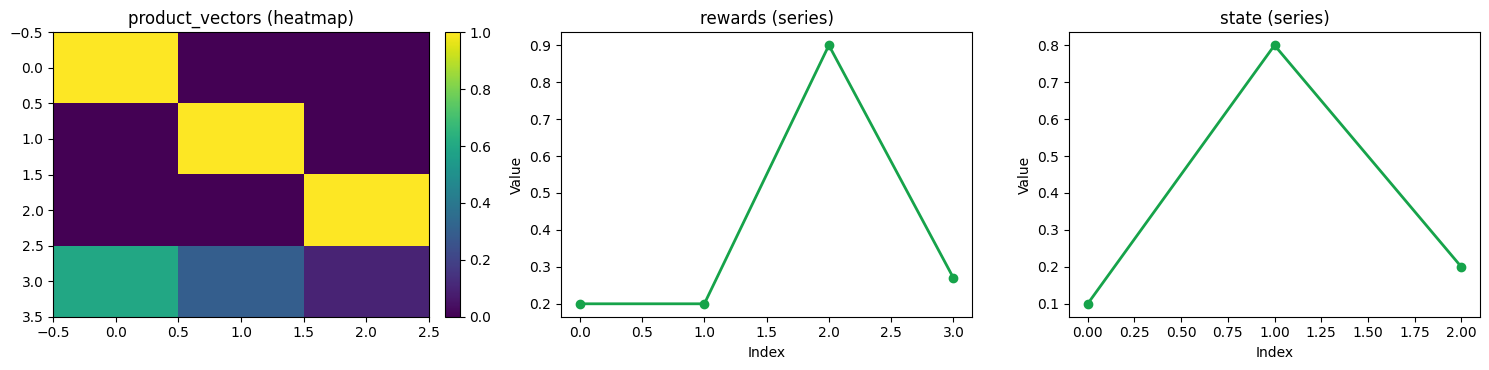

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Define function `_is_number`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Define function `_as_numeric_dict`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Define function `_as_numeric_array`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # Execute: "functions": sum(callable(value) for value in globals().values()),
        "functions": sum(callable(value) for value in globals().values()),
        # Execute: "classes": sum(isinstance(value, type) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # Execute: "numeric vars": sum(_is_number(value) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can choose and explain RL ideas in realistic application settings, not only in textbook examples.

**If students remember one idea:** The strongest sign of understanding is being able to justify why a method fits a task, what assumptions it needs, and what risks it carries.

**Quick check before moving on:**
- Can you explain why your chosen RL framing suits the application you discussed?
- Can you describe what challenge or limitation would matter most in a real deployment?

**Bridge to the next step:** After this exercise, students should be ready to integrate the whole course in the final project and assessment work.
